---

We study the iVi (integrated variance implicit) scheme
of [Abi Jaber (2025)](https://arxiv.org/abs/2412.11264) for the Heston model.

---

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from ivi_scheme import impvol_heston_ivi_scheme
from heston import impvol_heston_charfunc, simulate_variance_qe_scheme
from utils import black_otm_impvol_mc

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

## The iVi scheme

In [3]:
set_1 = {"V0": 0.006, "a": 17.25 * 0.018, "b": -17.25, "c": 2.95, "rho": -0.68}
set_2 = {"V0": 0.023, "a": 2.15 * 0.057, "b": -2.15, "c": 0.86, "rho": -0.70}
set_3 = {"V0": 0.04, "a": 0.5 * 0.04, "b": -0.5, "c": 1.0, "rho": -0.90}

dict_sets = {"set_1": set_1, "set_2": set_2, "set_3": set_3}

In [4]:
n_disc = 100  # number of time-steps
n_paths = 10**5  # number of Monte Carlo paths
T = 0.1  # maturity
ks = np.linspace(-0.2, 0.1, 101)  # log-moneynesses

In [5]:
params = dict_sets["set_2"]

params_heston = {
    "v": params["V0"],
    "lbd": -params["b"],
    "vbar": -params["a"] / params["b"],
    "nu": params["c"],
    "rho": params["rho"],
    "S0": 1.0,
}

Characteristic function

In [6]:
impvols_hst_cf = impvol_heston_charfunc(ks, T, params_heston)

iVi scheme

In [7]:
impvols_hst_ivi = impvol_heston_ivi_scheme(
    ks, T, params_heston, n_disc=n_disc, n_paths=n_paths, seed=SEED
)

QE scheme

In [29]:
S_qe, v_qe = simulate_variance_qe_scheme(
    T=T, params=params_heston, n_disc=n_disc, n_paths=n_paths, seed=SEED
)

In [30]:
impvols_hst_qe = black_otm_impvol_mc(S_qe[-1, :], ks, T=T)
impvols_hst_qe = np.asarray(impvols_hst_qe)

Plot

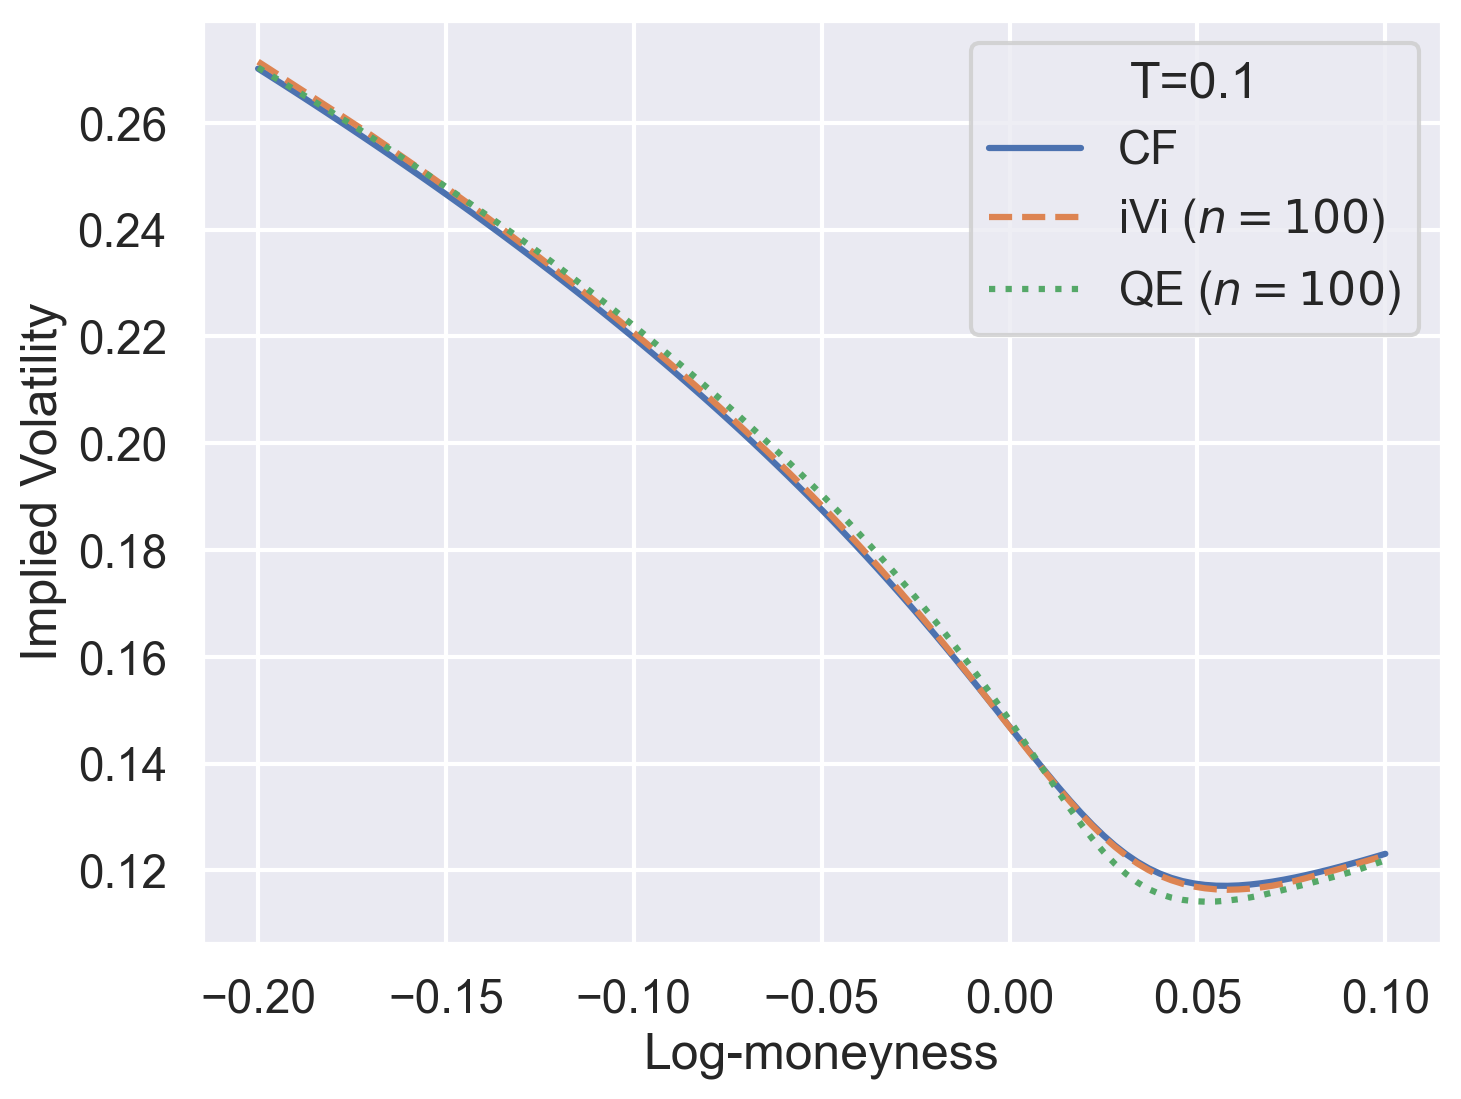

In [31]:
fig, ax = plt.subplots()
ax.plot(ks, impvols_hst_cf, label="CF")
ax.plot(ks, impvols_hst_ivi, "--", label=rf"iVi ($n={n_disc}$)")
ax.plot(ks, impvols_hst_qe, ":", label=rf"QE ($n={n_disc}$)")
ax.legend(title=f"T={T}")
ax.set_xlabel(r"Log-moneyness")
ax.set_ylabel("Implied Volatility")
plt.show()

## Quadratic Exponential (QE) scheme

[Andersen 2008](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=946405)

**Model**

\begin{aligned}
dS_t &=  \sqrt{v_t}\,S_t\,dW^{(1)}_t,\\
dv_t &= \kappa(\theta - v_t)\,dt + \sigma \sqrt{v_t}\,dW^{(2)}_t, \qquad
d\langle W^{(1)}, W^{(2)}\rangle_t = \rho\,dt .
\end{aligned}

**One-step moments of $v_{t+\Delta}$ given $v_t=v$**

Let $\Delta$ be the time step and $v=v_t$.

$$
m = \Bbb{E}[v_{t+\Delta}\mid v] = \theta + (v-\theta)e^{-\kappa \Delta},
$$

$$
s^2 = \operatorname{Var}(v_{t+\Delta}\mid v)
  = \frac{\sigma^2}{\kappa}\,e^{-\kappa\Delta}\!\left(v(1-e^{-\kappa\Delta})\right)
    + \frac{\theta\sigma^2}{2\kappa}\,(1-e^{-\kappa\Delta})^2,
$$

$$
\psi=\frac{s^2}{m^2}.
$$

- A practical switch is $\psi_c \approx 1.5$.

### Step 1 - QE draw for $v_{t+\Delta}$

**Regime 1 (Quadratic form)** $\psi \leq \psi_c$:

Draw $Z \sim \mathcal{N}(0,1)$ and set

$$
b^2 = \frac{2 + 2\sqrt{1 - \psi/2} - \psi}{\psi},
\qquad
a = \frac{m}{1 + b^2},
\qquad
v_{t+\Delta} = a\,(b + Z)^2.
$$

**Regime 2 (Exponential form)** $\psi > \psi_c$:

Let 

$$
    p = \frac{\psi - 1}{\psi + 1},
    \qquad
    \beta = \frac{m(\psi + 1)}{2}.
$$

Draw $U \sim \mathcal{U}(0,1)$. If $U \leq p$, set $v_{t+\Delta} = 0$; 
else draw $U^\prime \sim \mathcal{U}(0,1)$ and set $v_{t+\Delta} = \beta \log\left(\frac{1}{U^\prime}\right)$.

### Step 2 - Log-price update over $[t, t+\Delta]$

Let $I = \int_t^{t+\Delta} v_u\,du$. Using the variance SDE, 

$$
    \int_t^{t+\Delta} \sqrt{v_s} dW^{(2)}_s
    = \frac{1}{\sigma}\left(v_{t+\Delta} - v_t - \kappa\theta\Delta + \kappa I\right).
$$

The log-price increment is 

$$
    \log(S_{t+\Delta}/S_t)
    = -\frac{1}{2}I + \rho \int_t^{t+\Delta} \sqrt{v_s} dW^{(2)}_s
      + \sqrt{1-\rho^2} \sqrt{I} Z_2,
$$

where $Z_2 \sim \mathcal{N}(0,1)$ independent of $W^{(2)}$.

- Use trapezoidal rule to approximate $I$:

$$
    I \approx \frac{\Delta}{2} \left(v_t + v_{t+\Delta}\right).
$$